# Gráfico de dispersão no Matplotlib

O gráfico de dispersão é a opção certa para **encontrar a relação, correlação ou padrão entre duas variáveis numéricas**. Em vez de uma linha contínua ligando os valores, ele plota cada par de dados como um **ponto isolado** no gráfico.

O exemplo desta página vem de uma rede social: cada usuário tem uma quantidade de amigos e um tempo diário de uso do site. A pergunta é simples — **quem tem mais amigos passa mais tempo no site?**

In [1]:
%matplotlib inline

from matplotlib import pyplot as plt

## 1. O import

`pyplot` é o módulo que cuida de *desenhar*. O `as plt` cria um **apelido**: em vez de digitar `pyplot.scatter(...)`, você digita só `plt.scatter(...)`.

O `%matplotlib inline` é um comando do **IPython**, não do Python. Ele manda o Matplotlib desenhar o gráfico **dentro do próprio notebook**, em vez de abrir uma janela separada.

## 2. Os dados

São **9 usuários**, medidos em duas variáveis numéricas. Cada lista guarda uma variável inteira, e a **ordem dos elementos** é o que amarra uma pessoa à sua própria linha:

| Lista | O que guarda | Vai para |
| --- | --- | --- |
| `friends` | número de amigos de cada usuário | eixo x |
| `minutes` | minutos por dia no site | eixo y |
| `labels` | a letra que identifica cada usuário | o rótulo do ponto |

In [2]:
friends = [70, 65, 72, 63, 71, 64, 60, 64, 67]
minutes = [175, 170, 205, 120, 220, 130, 105, 145, 190]
labels = ["a", "b", "c", "d", "e", "f", "g", "h", "i"]

# as três listas andam juntas: o índice identifica a mesma pessoa
for label, friend, minute in zip(labels, friends, minutes):
    print(f"{label}: {friend} amigos, {minute} min")

a: 70 amigos, 175 min
b: 65 amigos, 170 min
c: 72 amigos, 205 min
d: 63 amigos, 120 min
e: 71 amigos, 220 min
f: 64 amigos, 130 min
g: 60 amigos, 105 min
h: 64 amigos, 145 min
i: 67 amigos, 190 min


Os mesmos dados em tabela:

| Rótulo | `friends` (x) | `minutes` (y) |
| --- | --- | --- |
| a | 70 | 175 |
| b | 65 | 170 |
| c | 72 | 205 |
| d | 63 | 120 |
| e | 71 | 220 |
| f | 64 | 130 |
| g | 60 | 105 |
| h | 64 | 145 |
| i | 67 | 190 |

Repare que `friends` **repete o valor `64`** (usuários `f` e `h`). Isso vai aparecer no gráfico como dois pontos na mesma coluna vertical, um a 130 e outro a 145 minutos.

O `zip()` aqui é o mesmo do [*Gráfico de Linha*](grafico-linha.ipynb): ele caminha pelas listas **par a par** e para na mais curta.

## 3. `plt.scatter` — uma chamada desenha os nove pontos

Esse é o coração do gráfico. Uma única chamada já recebe **as duas listas inteiras**:

```python
plt.scatter(friends, minutes)
```

Três coisas importantes:

- O **primeiro argumento é sempre o eixo x** e o **segundo é sempre o eixo y**. Não existe `x=` ou `y=` aqui: a posição do argumento é o que define o eixo.
- Não existe `for` para desenhar ponto a ponto. O Matplotlib lê as duas listas na mesma posição e coloca um ponto para cada par — por isso uma chamada desenha nove pontos.
- Como não há linha ligando os pontos, o gráfico fica com o formato de uma **nuvem**. É essa nuvem que denuncia a relação entre as variáveis.

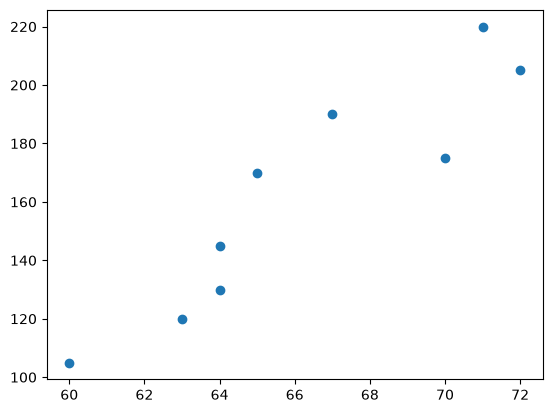

In [3]:
plt.scatter(friends, minutes)

## 4. O `for` com `zip` — rotulando cada ponto

Só com o `scatter` você vê nove bolinhas anônimas. Para saber que a bolinha em 71 amigos é a pessoa `e`, é preciso **escrever a letra em cima de cada ponto**. Como o `scatter` não faz isso sozinho, usamos um `for` com `plt.annotate`:

```python
for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(
        label,
        xy=(friend_count, minute_count),
        xytext=(5, -5),
        textcoords="offset points",
    )
```

O `for` anda pelas três listas ao mesmo tempo e entrega **um Users letra, um número de amigos e um número de minutos por volta**. É o mesmo `zip` da seção 2, agora servindo para escrever texto.

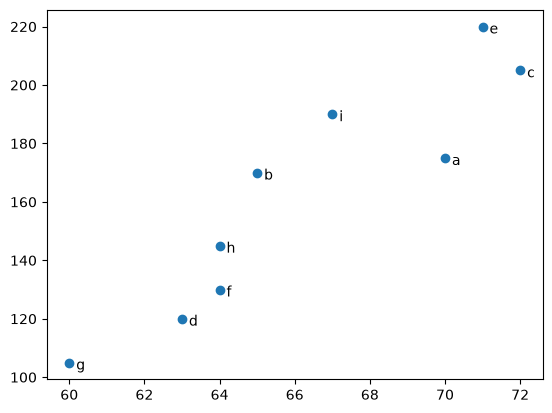

In [4]:
plt.scatter(friends, minutes)

# rotule cada ponto
for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(
        label,
        xy=(friend_count, minute_count),  # Coloque o rótulo no respectivo ponto
        xytext=(5, -5),  # mas levemente deslocado
        textcoords="offset points",
    )

## 5. `plt.annotate` — os três argumentos que importam

O `annotate` parece complicado, mas são só três peças:

| Argumento | O que faz |
| --- | --- |
| `label` | o **texto** a escrever — a letra `"a"`, `"b"`, `"c"`... |
| `xy=(friend_count, minute_count)` | o **ponto exato** onde o texto pertence, em coordenadas de dados |
| `xytext=(5, -5)` | onde o texto vai ficar |
| `textcoords="offset points"` | como interpretar esse `xytext` |

### Por que `textcoords="offset points"` é obrigatório

Esse é o detalhe que faz o gráfico ficar legível, e é o mais fácil de errar sem saber o porquê. O `xytext` **não é um deslocamento** por padrão — ele é uma **posição absoluta**, e o `textcoords` é quem decide em que sistema essa posição é medida:

- **Com `"offset points"`** → `xytext` é lido como um **deslocamento em pontos de tela** (1 ponto = 1/72 de polegada) a partir do `xy`. O mesmo `(5, -5)` serve para os nove pontos, e continua igual se você salvar a figura em alta resolução ou redimensionar a janela.
- **Sem essa linha** → o Matplotlib assume que `xytext` está em **coordenadas de dados**, o mesmo sistema dos eixos. E aí o resultado é pior do que parece: `(5, -5)` deixa de ser um deslocamento e passa a significar o **ponto absoluto x=5, y=5 negativo**. Como os eixos vão de x 59 a 73 e de y 99 a 226, essa posição está **bem fora do gráfico** — e, pior, as **nove letras se empilham exatamente no mesmo lugar**, todas no mesmo ponto `(5, -5)`, em vez de cada uma perto do seu ponto.

Ou seja: sem `textcoords`, o `xytext` deixa de ser relativo. É ele que transforma `(5, -5)` em "cinco pontos à direita e cinco para baixo **daquele** ponto".

O sinal também importa: `+5` no primeiro número anda para a **direita**, `-5` no segundo desce um pouco (o eixo y cresce para cima). O resultado é a letra **encostada na parte de baixo e à direita** da bolinha, sem cobrir o ponto.

Se você quiser a letra **dentro** do ponto, é só usar `xytext=(0, 0)`. Funciona — mas a bolinha some sob o texto.

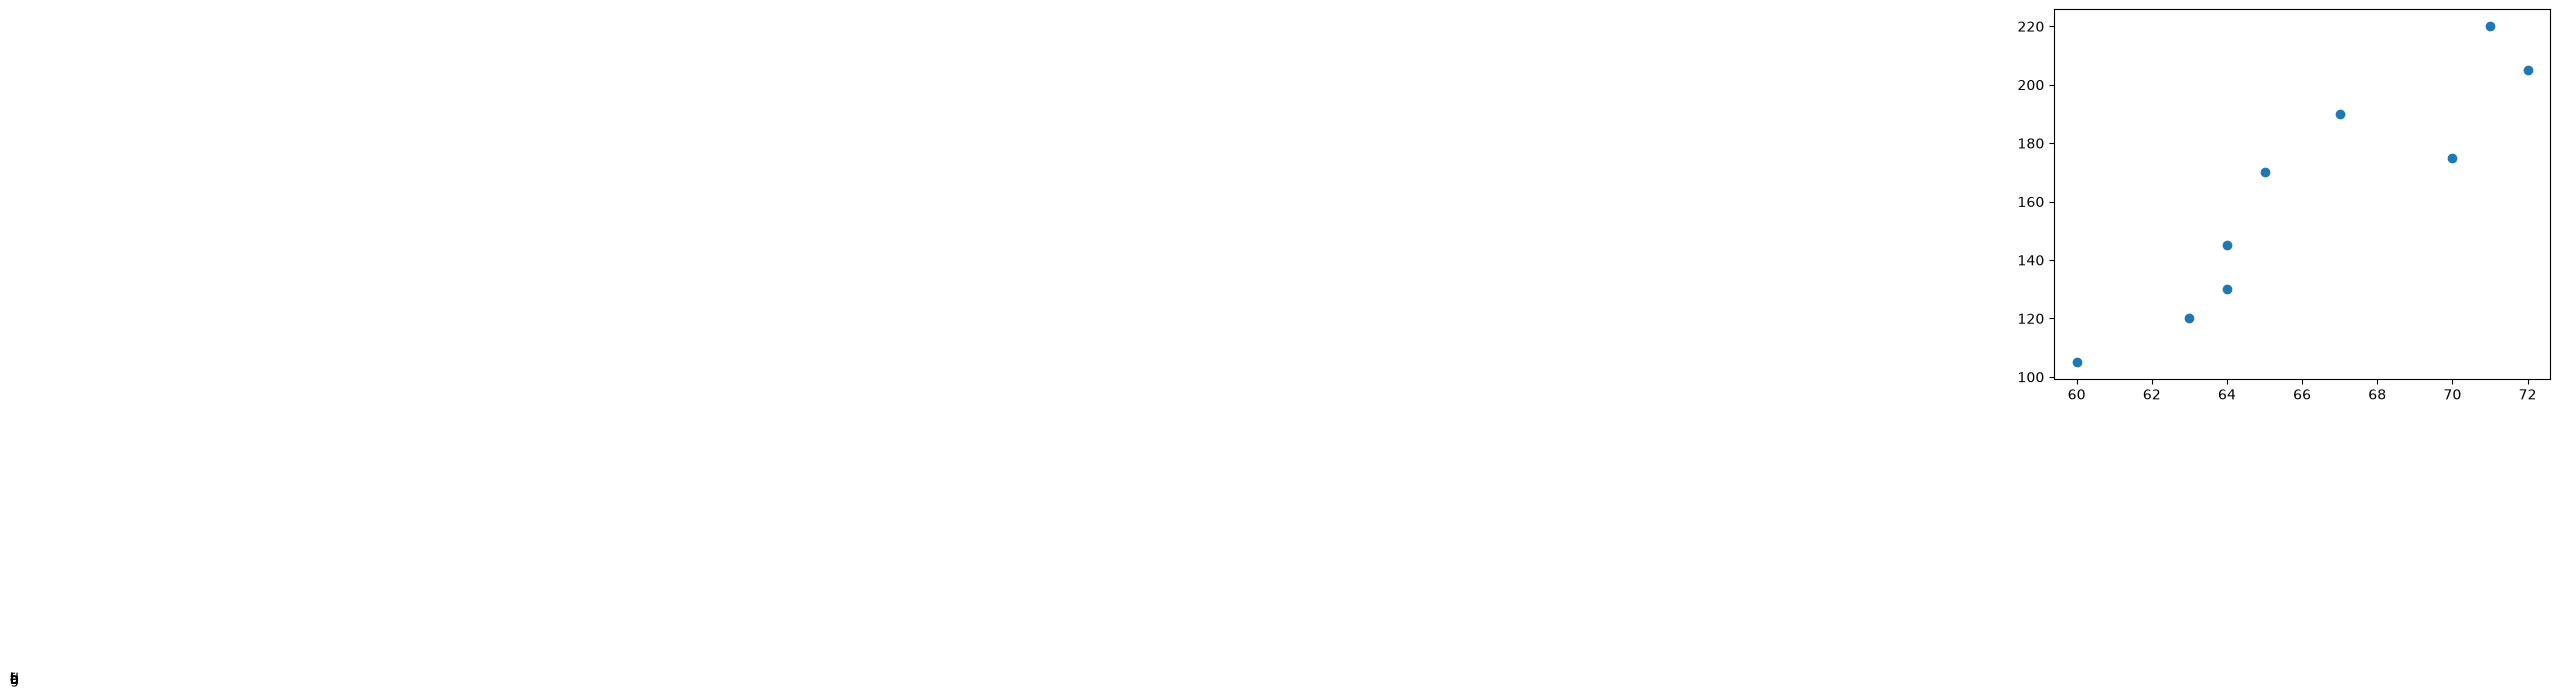

In [5]:
plt.scatter(friends, minutes)

# versao com o offset em unidades de dados, para comparar
for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(
        label,
        xy=(friend_count, minute_count),
        xytext=(5, -5),  # sem textcoords: 5 e -5 viram unidades de DADOS
    )

Compare os dois gráficos: no primeiro os rótulos ficam colados nos seus pontos. No segundo o mesmo `xytext=(5, -5)` virou **posição absoluta** — as nove letras foram parar empilhadas num ponto `(5, -5)` fora da área do gráfico, e o resultado é uma nuvem de bolinhas **sem nenhum rótulo**.

## 6. Título e rótulos dos eixos

Falta dizer ao leitor o que cada eixo significa. São três chamadas, todas fora do `for`:

```python
plt.title("Daily Minutes vs. Number of Friends")
plt.xlabel("# of friends")
plt.ylabel("daily minutes spent on the site")
plt.show()
```

- `title` dá o título.
- `xlabel` e `ylabel` nomeiam os eixos — **o número sozinho não diz nada**. O `70` no eixo x só vira informação quando alguém lê *"# of friends"*.
- `plt.show()` é o que **efetivamente desenha** a janela. Até aqui, todas as chamadas só estavam montando o gráfico em memória.

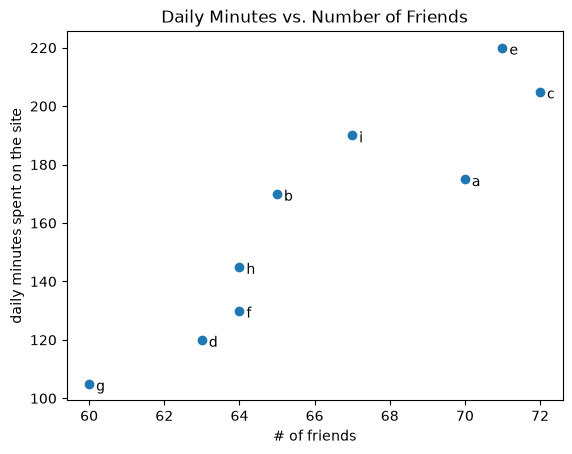

In [6]:
plt.scatter(friends, minutes)

# rotule cada ponto
for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(
        label,
        xy=(friend_count, minute_count),  # Coloque o rótulo no respectivo ponto
        xytext=(5, -5),  # mas levemente deslocado
        textcoords="offset points",
    )

plt.title("Daily Minutes vs. Number of Friends")
plt.xlabel("# of friends")
plt.ylabel("daily minutes spent on the site")
plt.show()

## 7. O detalhe de indentação

No script original deste exercício, as quatro últimas linhas estavam **recuadas para dentro do `for`**. Isso faz `plt.show()` rodar uma vez por usuário — **nove janelas** (ou nove renderizações repetidas no notebook), em vez de uma.

A diferença entre a versão errada e a certa é só o recuo das linhas:

In [7]:
errado = """for label, friend, minute in zip(labels, friends, minutes):
    plt.annotate(label, xy=(friend, minute), xytext=(5, -5), textcoords="offset points")
    plt.title("Daily Minutes vs. Number of Friends")
    plt.show()"""

certo = """for label, friend, minute in zip(labels, friends, minutes):
    plt.annotate(label, xy=(friend, minute), xytext=(5, -5), textcoords="offset points")

plt.title("Daily Minutes vs. Number of Friends")
plt.show()"""


def dentro_do_for(codigo):
    """Conta as linhas recuadas, ou seja, as que repetem a cada volta do for."""
    return sum(1 for linha in codigo.splitlines() if linha.startswith("    "))


print("versao errada:", dentro_do_for(errado), "linhas repetidas a cada iteracao")
print("versao certa :", dentro_do_for(certo), "linha repetida a cada iteracao")
print("total de iteracoes do for:", len(labels))

versao errada: 3 linhas repetidas a cada iteracao
versao certa : 1 linha repetida a cada iteracao
total de iteracoes do for: 9


Como o `for` dá **9 voltas**, a versão errada chama `plt.show()` **9 vezes**. O gráfico em si fica correto (o `plt.title` reescreve o mesmo título a cada volta), mas o programa abre nove janelas ou desenha o mesmo gráfico nove vezes seguidas.

**Regra:** chamadas que descrevem o gráfico inteiro (`title`, `xlabel`, `ylabel`, `legend`, `show`) ficam **fora** do `for`. Só o que é **por ponto** fica dentro.

## 8. O que o gráfico mostra

Os pontos sobem da esquerda para a direita: quem tem mais amigos também passa mais tempo no site. Isso é o que o gráfico de dispersão existe para revelar — uma **nuvem que se inclina** é o sinal visual de correlação.

Dá para confirmar numericamente com o **coeficiente de correlação de Pearson** (`r`), que mede o quanto as duas variáveis andam juntas, de `-1` a `+1`:

In [8]:
import math

media_amigos = sum(friends) / len(friends)
media_minutos = sum(minutes) / len(minutes)

# o quanto cada ponto se desvia da média, multiplicado e somado
covariancia = sum(
    (f - media_amigos) * (m - media_minutos) for f, m in zip(friends, minutes)
)
desvio_amigos = math.sqrt(sum((f - media_amigos) ** 2 for f in friends))
desvio_minutos = math.sqrt(sum((m - media_minutos) ** 2 for m in minutes))

r = covariancia / (desvio_amigos * desvio_minutos)

print(f"r = {r:.3f}")
if r > 0.8:
    print("correlacao forte e positiva")
elif r > 0.5:
    print("correlacao moderada")
else:
    print("correlacao fraca")

r = 0.922
correlacao forte e positiva


Com **`r ≈ 0.92`**, a relação é **forte e positiva**: a nuvem sobe de forma bem regular, sem muitos pontos fora do caminho. Compare com o `c` (72 amigos, 205 min) e o `g` (60 amigos, 105 min) — os dois extremos seguem a tendência.

Uma ressalva importante: **correlação não é causal**. O gráfico mostra que os dois números andam juntos, mas não prova que fazer mais amigos cause passar mais tempo no site. Pode ser o contrário, ou os dois dependerem de uma terceira coisa — por exemplo, o tempo de uso.

E os rótulos importam justamente para isso: sem as letras, você veria a nuvem e a correlação, mas **não saberia** que os pontos `f` e `h` são duas pessoas diferentes com os mesmos 64 amigos.

## Armadilhas comuns

- **Deixar `plt.title` / `plt.show` dentro do `for`** → o script abre 9 janelas (ou renderiza 9 vezes no notebook). Essas chamadas pertencem ao gráfico inteiro, não a cada ponto.
- **Trocar a ordem em `plt.scatter`** → o primeiro argumento é **sempre** o x. `plt.scatter(minutes, friends)` desenha o gráfico deitado, com minutos no eixo horizontal.
- **Listas de tamanhos diferentes em `zip`** → o `zip` **para na lista mais curta, sem nenhum aviso**. Se `labels` tivesse 7 letras, apenas 7 pontos seriam rotulados e ninguém percebia.
- **Esquecer `textcoords="offset points"`** → o `xytext` deixa de ser um deslocamento e passa a ser uma **posição absoluta em coordenadas de dados**. As nove letras se empilham no mesmo ponto `(5, -5)`, fora do gráfico, e o resultado sai sem rótulo nenhum.
- **Reordenar só uma das listas** → cada pessoa passa a ser comparada com a pessoa errada, e a correlação mede outra coisa. As listas são colunas da mesma tabela: mexer em uma exige mexer nas outras.
- **Deixar `xytext=(0, 0)`** → a letra fica sobre a bolinha e some. Um deslocamento pequeno é o que torna o rótulo legível.
- **Esperar o `plt.show()` no meio do script** → até a última chamada, nada aparece: o Matplotlib só monta o desenho em memória até alguém pedir a exibição.